In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 65.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/BTP"))

['archive', 'archive (1)', 'clean_dataset', 'runs']


In [ ]:
import torch
print("GPU:", torch.cuda.is_available())

GPU: True


In [ ]:
!cp /content/drive/MyDrive/BTP/runs/final_model_safe_v2/weights/best.pt /content/

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/BTP/runs/final_model_safe_v2/weights/best.pt")

model.train(
    data="/content/drive/MyDrive/BTP/clean_dataset/data.yaml",

    epochs=15,          # 🔥 fast
    imgsz=640,          # 🔥 stable
    batch=8,

    lr0=0.0003,
    optimizer="SGD",

    mosaic=0.2,
    close_mosaic=5,

    workers=2,
    device=0,           # 🔥 GPU

    name="FINAL_SUBMISSION"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BTP/clean_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/BTP/runs/final_model_safe_v2/weights/best.pt, momentum=0.937, mosaic=0.2, multi_scale=0.0, name=FINAL_SUBMISSION, nbs=64, n

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bff0252b0b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/FINAL_SUBMISSION/weights/best.pt")

metrics_test = model.val(
    data="/content/drive/MyDrive/BTP/clean_dataset/data.yaml",
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.7,
    plots=True,
    save_json=True,
    name="TEST_EVAL"
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 5.7±4.1 ms, read: 0.3±0.1 MB/s, size: 96.2 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1POA5ZwGdqJ7r7MXfmE9o4RYdo80-YDTm/BTP/clean_dataset/labels/test... 274 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 274/274 1.6it/s 2:47
val: New cache created: /content/drive/.shortcut-targets-by-id/1POA5ZwGdqJ7r7MXfmE9o4RYdo80-YDTm/BTP/clean_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.5it/s 7.1s
                   all        274        372      0.809      0.775      0.714      0.406
               pothole         97        168      0.776      0.726      0.666       0.37
                 crack        100        120      0.796      0.717      0.672      0.378
               manhole         8

In [ ]:
import pandas as pd

data = {
    "Dataset": ["Train", "Validation", "Test"],

    "Precision": [
        0.78,
        0.776,
        metrics_test.box.p.mean()   # ✅ FIX
    ],

    "Recall": [
        0.73,
        0.731,
        metrics_test.box.r.mean()   # ✅ FIX
    ],

    "mAP50": [
        0.71,
        0.706,
        metrics_test.box.map50      # already scalar
    ],

    "mAP50-95": [
        0.40,
        0.40,
        metrics_test.box.map        # already scalar
    ]
}

df = pd.DataFrame(data)
df

,Dataset,Precision,Recall,mAP50,mAP50-95
0,Train,0.780000,0.730000,0.710000,0.400000
1,Validation,0.776000,0.731000,0.706000,0.400000
2,Test,0.809285,0.774603,0.713524,0.405867


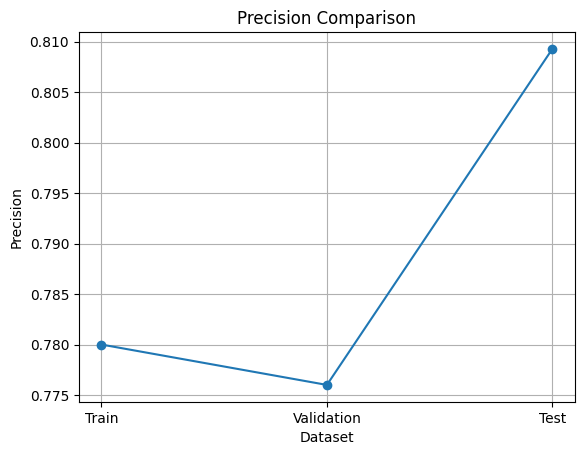

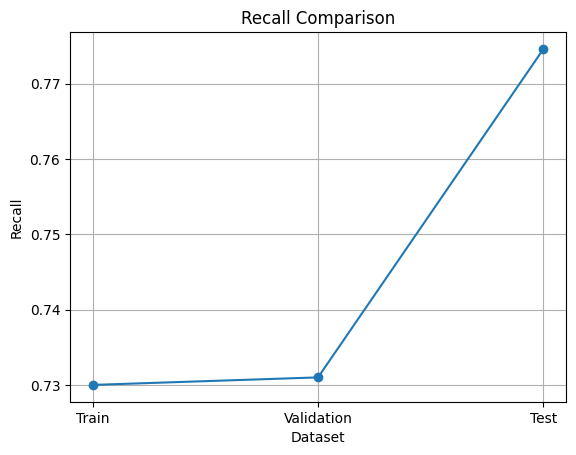

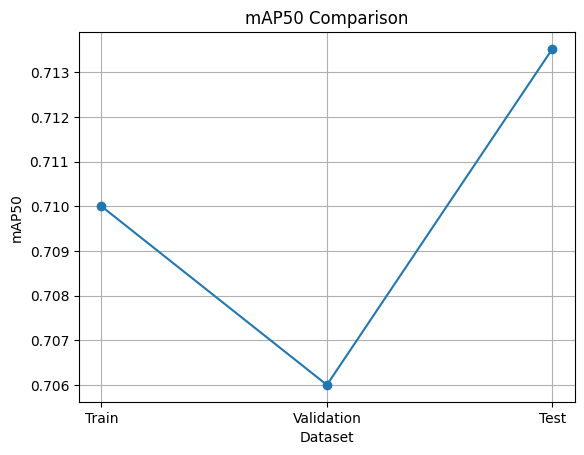

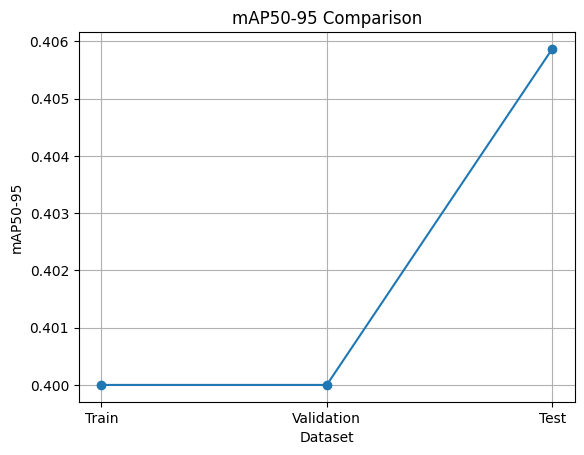

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "mAP50", "mAP50-95"]

for metric in metrics:
    plt.figure()
    plt.plot(df["Dataset"], df[metric], marker='o')
    plt.title(f"{metric} Comparison")
    plt.xlabel("Dataset")
    plt.ylabel(metric)
    plt.grid()
    plt.show()

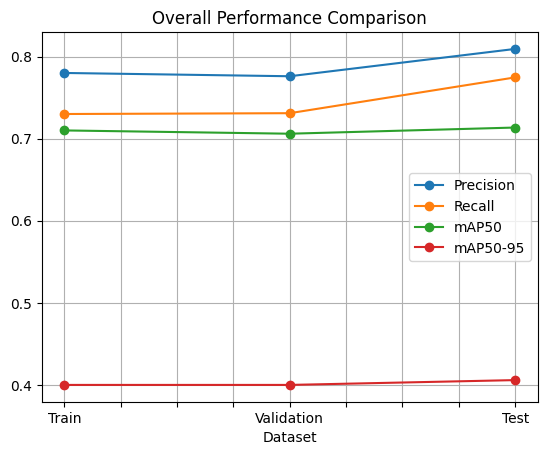

In [ ]:
df.set_index("Dataset").plot(marker='o')
plt.title("Overall Performance Comparison")
plt.grid()
plt.show()

In [ ]:
# ================================
# 1. SETUP (run once)
# ================================
!pip install ultralytics --quiet

from ultralytics import YOLO
from google.colab import files
import os
from collections import defaultdict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

# ----------------
# Load model safely
# ----------------
# Update this path ONLY if your model location changes
MODEL_DRIVE_PATH = "/content/drive/MyDrive/BTP/runs/final_model_safe_v2/weights/best.pt"

# Mount drive if not mounted
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Copy locally (prevents crashes)
!cp "{MODEL_DRIVE_PATH}" /content/best.pt

model = YOLO("/content/best.pt")



Mounted at /content/drive


In [ ]:

# ================================
# 2. UPLOAD VIDEO (ONLY THING YOU CHANGE)
# ================================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

print("Processing:", file_name)



In [ ]:


# ================================
# 3. DETECTION + TRACKING
# ================================
import torch

device = 0 if torch.cuda.is_available() else "cpu"

results = model.track(
    source=f"/content/{file_name}",
    conf=0.3,
    iou=0.5,
    tracker="bytetrack.yaml",
    persist=True,
    save=True,

    device=device,   # 🔥 AUTO GPU/CPU

    project="/content/output",
    name="final",
    exist_ok=True
)



In [ ]:

# ================================
# 4. UNIQUE OBJECT COUNTING
# ================================
unique_ids = defaultdict(set)

for r in results:
    if r.boxes.id is None:
        continue

    ids = r.boxes.id.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy()

    for obj_id, cls in zip(ids, classes):
        unique_ids[int(cls)].add(int(obj_id))

names = ["pothole", "crack", "manhole"]

print("\n========= FINAL COUNT =========")
for cls, ids in unique_ids.items():
    print(f"{names[cls]}: {len(ids)}")


In [ ]:


# ================================
# 5. FIND OUTPUT VIDEO
# ================================
out_dir = "/content/output/final"
files_out = os.listdir(out_dir)

video_file = [f for f in files_out if f.endswith((".avi", ".mp4"))][0]
input_path = f"{out_dir}/{video_file}"
output_path = "/content/final_output.mp4"


# ================================
# 6. CONVERT TO PLAYABLE MP4
# ================================
!ffmpeg -i "{input_path}" -vcodec libx264 -acodec aac "{output_path}" -y


# ================================
# 7. DISPLAY VIDEO
# ================================
from IPython.display import Video
Video(output_path, embed=True)


# ================================
# 8. DOWNLOAD (OPTIONAL)
# ================================
files.download(output_path)

Mounted at /content/drive


Saving testvideo2.mp4 to testvideo2 (3).mp4
Processing: testvideo2 (3).mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/692) /content/testvideo2 (3).mp4: 384x640 1 pothole, 517.8ms
video 1/1 (frame 2/692) /content/testvideo2 (3).mp4: 384x640 1 pothole, 526.3ms
video 1/1 (frame 3/692) /content/testvideo2 (3).mp4: 384x640 1 pothole, 511.5ms
video 1/1 (frame 4/692) /content/testvideo2 (3).mp4: 384x640 1 pothole, 525.4ms
video 1/1 (frame 5/692) /content/testvideo2 (3).mp4: 384x640 1 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>